# 🛰️ Sentinel-2 & Sentinel-5P Paired Data Pipeline for Multi-Pollutant Downscaling
### Project: *Satellite-Driven Multi-Pollutant Forecasting for Industrial & Respiratory Disease Risk Mapping*
**Core Architecture:** Area-Weighted Spatial Downscaling & Temporal ConvLSTM (RTX 4070 8GB VRAM Optimized)

---

### 📌 Why Both Streams are Required (The Downscaling Formulation)
* **Sentinel-2 (High-Res Input, ~100m):** Provides 12 spatial feature channels (Visible, Red-Edge, SWIR surface reflectance + NDBI, NDVI, NDMI). These physical indices pinpoint *where* emissions occur (factories, industrial parks, roads vs. vegetation/water).
* **Sentinel-5P (Coarse Supervision, ~5000m):** Provides column number densities of **NO₂**, **CO**, and **SO₂**.
* **Area-Weighted Consistency Loss:** The model takes S2 patches as input and predicts a fine-resolution gas map $\hat{Y}_{\text{fine}}$. The loss enforces that the spatial average of $\hat{Y}_{\text{fine}}$ inside each coarse S5P pixel matches the observed S5P value:
$$\mathcal{L}_{\text{consistency}} = \frac{1}{M} \sum_{m=1}^M \left| \frac{1}{|\Omega_m|} \sum_{p \in \Omega_m} \hat{Y}_{\text{fine}}(p) - Y_{\text{S5P}}(m) \right|$$

---

### ⚙️ Pipeline Specifications:
* **Region of Interest (AOI):** Chennai Industrial Corridor `[79.95°E, 12.80°N, 80.45°E, 13.30°N]` (~55 km × 55 km). Encompasses Manali Petrochemical cluster, Ennore Thermal Power Station, Ambattur/Guindy industrial zones, and Chennai Port.
* **Temporal Window:** 5-day median composites from **2019-01-01 to 2024-12-31** (~438 windows).
* **S2 Channels (12):** B2, B3, B4, B5, B6, B7, B8, B11, B12 + NDVI, NDBI, NDMI.
* **S5P Channels (3):** NO2, CO, SO2 (all QA-filtered $> 0.5$).
* **Storage Footprint:** ~4.5 GB total for S2 + ~40 MB for S5P (comfortably fits on Google Drive).

In [2]:
# ==============================================================================
# Cell 1: Install Dependencies & Mount Google Drive / Local Setup
# ==============================================================================
import sys
import subprocess

# Auto-install dependencies if not already present
required_packages = ["earthengine-api", "geemap", "rasterio", "matplotlib", "tqdm", "pandas"]
for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
import time
import datetime
import numpy as np
import pandas as pd
import rasterio
import requests
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Earth Engine & Colab / Local Setup
import ee

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Satellite_Downscaling_Project'
    print("✓ Running in Google Colab. Storage set to Google Drive.")
except ImportError:
    IN_COLAB = False
    BASE_DIR = os.path.abspath('./satellite_data')
    print("✓ Running in local environment. Storage set to local directory.")

# Initialize Earth Engine using your saved credentials
try:
    ee.Initialize()
    print("✓ Earth Engine successfully initialized!")
except Exception as e:
    print("Authenticating Earth Engine...")
    ee.Authenticate()
    ee.Initialize()
    print("✓ Earth Engine authenticated and initialized successfully!")


Installing earthengine-api...
✓ Running in local environment. Storage set to local directory.
✓ Earth Engine successfully initialized!


## 🗺️ Step 1: Study Area & Pipeline Configuration
We define the bounding box covering the **Chennai Industrial Corridor** and set the composite parameters.

In [ ]:
# ==============================================================================
# Cell 2: Configuration Parameters (WHOLE TAMIL NADU - Coastline-Safe)
# ==============================================================================
CONFIG = {
    # Full Tamil Nadu Bounding Box with coastal buffer
    # Eastern edge at 80.40°E ensures ALL shoreline, ports (Chennai, Tuticorin,
    # Nagapattinam, Cuddalore), and Pulicat Lake are fully captured.
    # [min_lon, min_lat, max_lon, max_lat]
    "BBOX": [76.20, 8.05, 80.40, 13.55],

    # Date Range (2019 - 2024)
    "START_DATE": "2019-01-01",
    "END_DATE": "2024-12-31",
    "WINDOW_DAYS": 5,

    # Resolutions (meters)
    "SCALE_S2": 600,    # 600m: fits GEE 48MB limit for full TN, ~15MB/tif
    "SCALE_S5P": 5000,  # 5000m: ~92x122 pixels, ~45KB/tif. Native S5P footprint.

    # Scene-level cloud filter (relaxed to 85% because pixel-level SCL does the
    # real filtering; this prevents discarding coastal tiles that have clouds
    # over the ocean but clear skies over land)
    "MAX_S2_CLOUD_PERCENT": 85,

    # Storage Paths
    "OUTPUT_DIR": BASE_DIR,
    "S2_DIR": os.path.join(BASE_DIR, "data2", "s2_composites"),
    "S5P_DIR": os.path.join(BASE_DIR, "data2", "s5p_composites"),
    "MANIFEST_PATH": os.path.join(BASE_DIR, "data2", "dataset_manifest.csv")
}

# Create required directories
os.makedirs(CONFIG["S2_DIR"], exist_ok=True)
os.makedirs(CONFIG["S5P_DIR"], exist_ok=True)

# Define Earth Engine Geometry
AOI = ee.Geometry.Rectangle(CONFIG["BBOX"])

print(f"Project Base Directory: {CONFIG['OUTPUT_DIR']}")
print(f"S2 Directory:          {CONFIG['S2_DIR']}")
print(f"S5P Directory:         {CONFIG['S5P_DIR']}")
print(f"Manifest File:         {CONFIG['MANIFEST_PATH']}")
print(f"AOI Coordinates:       {CONFIG['BBOX']}")

Project Base Directory: /content/drive/MyDrive/Satellite_Downscaling_Project
S2 Directory:          /content/drive/MyDrive/Satellite_Downscaling_Project/data2/s2_composites
S5P Directory:         /content/drive/MyDrive/Satellite_Downscaling_Project/data2/s5p_composites
Manifest File:         /content/drive/MyDrive/Satellite_Downscaling_Project/data2/dataset_manifest.csv
AOI Coordinates:       [76.2, 8.05, 80.4, 13.55]


## 🛰️ Step 2: Interactive AOI Verification
Inspect the region of interest covering **all of Tamil Nadu** with complete coastline.
Key industrial sites and ports that must be visible:
* **North:** Chennai Port, Ennore Thermal Power, Pulicat Lake
* **Central:** Cuddalore SIPCOT, Neyveli Lignite, Nagapattinam Port
* **South:** Tuticorin Port & Thermal, Sterlite Copper, Kanyakumari
* **West:** Coimbatore Industrial Belt, Salem Steel Plant

In [ ]:
# ==============================================================================
# Cell 3: Visualize AOI on Interactive Map
# ==============================================================================
import geemap

Map = geemap.Map(center=[10.80, 78.30], zoom=7)
Map.add_basemap('HYBRID')

# Add AOI boundary box
aoi_style = {'color': 'cyan', 'width': 2, 'fillColor': '00000000'}
Map.addLayer(AOI, aoi_style, 'Study Area (Full Tamil Nadu)')

# Key industrial landmarks & ports across Tamil Nadu
industrial_sites = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([80.29, 13.09]), {'name': 'Chennai Port & Harbour'}),
    ee.Feature(ee.Geometry.Point([80.32, 13.20]), {'name': 'Ennore Thermal Power Station'}),
    ee.Feature(ee.Geometry.Point([80.26, 13.16]), {'name': 'Manali Industrial & Refinery'}),
    ee.Feature(ee.Geometry.Point([79.77, 11.74]), {'name': 'Cuddalore SIPCOT Industrial'}),
    ee.Feature(ee.Geometry.Point([79.47, 11.60]), {'name': 'Neyveli Lignite Complex'}),
    ee.Feature(ee.Geometry.Point([78.18, 11.66]), {'name': 'Salem Steel Plant'}),
    ee.Feature(ee.Geometry.Point([76.96, 11.00]), {'name': 'Coimbatore Industrial Belt'}),
    ee.Feature(ee.Geometry.Point([78.13, 9.93]),  {'name': 'Tuticorin Port & Thermal'}),
    ee.Feature(ee.Geometry.Point([77.56, 8.09]),  {'name': 'Kanyakumari (Southern Tip)'}),
    ee.Feature(ee.Geometry.Point([79.83, 10.78]), {'name': 'Nagapattinam Port'})
])
Map.addLayer(industrial_sites, {'color': 'red'}, 'Key Industrial Emission Hubs & Ports')
Map

Map(center=[10.8, 78.3], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

## ⏱️ Step 3: Temporal Window Generator
We divide the 2019–2024 timeline into uniform 5-day bins. Each bin gets a consistent timestamp ID (`YYYYMMDD`).

In [ ]:
# ==============================================================================
# Cell 4: Generate Synchronized 5-Day Time Windows
# ==============================================================================
def generate_time_windows(start_date_str, end_date_str, window_days=5):
    start = datetime.datetime.strptime(start_date_str, "%Y-%m-%d")
    end = datetime.datetime.strptime(end_date_str, "%Y-%m-%d")

    windows = []
    curr = start
    while curr + datetime.timedelta(days=window_days) <= end:
        w_start = curr.strftime("%Y-%m-%d")
        w_end = (curr + datetime.timedelta(days=window_days)).strftime("%Y-%m-%d")
        window_id = curr.strftime("%Y%m%d")
        windows.append({
            "window_id": window_id,
            "start_date": w_start,
            "end_date": w_end
        })
        curr += datetime.timedelta(days=window_days)
    return windows

TIME_WINDOWS = generate_time_windows(CONFIG["START_DATE"], CONFIG["END_DATE"], CONFIG["WINDOW_DAYS"])
print(f"Total synchronized 5-day windows generated: {len(TIME_WINDOWS)}")
print(f"First window: {TIME_WINDOWS[0]['start_date']} to {TIME_WINDOWS[0]['end_date']}")
print(f"Last window:  {TIME_WINDOWS[-1]['start_date']} to {TIME_WINDOWS[-1]['end_date']}")

Total synchronized 5-day windows generated: 438
First window: 2019-01-01 to 2019-01-06
Last window:  2024-12-25 to 2024-12-30


## 🔬 Step 4: Earth Engine Composite Engines
### S5P Multi-Gas Composite
* Queries Sentinel-5P Level-3 datasets for **NO₂**, **CO**, and **SO₂**.
* Applies standard QA quality flags (`qa_value >= 0.5`) to eliminate cloud-contaminated sounding points.
* Computes 5-day median reduction over the AOI.

### Sentinel-2 Multi-Spectral & Index Composite
* Uses `COPERNICUS/S2_SR_HARMONIZED` (Bottom-Of-Atmosphere Surface Reflectance).
* Applies the Scene Classification Layer (**SCL**) to mask clouds, cloud shadows, and cirrus.
* Extracts 9 physical spectral bands (B2, B3, B4, B5, B6, B7, B8, B11, B12).
* Computes 3 critical environmental proxies:
  * **NDBI** (Normalized Difference Built-up Index): $\frac{\text{B11} - \text{B8}}{\text{B11} + \text{B8}}$ (locates impervious/factory surfaces)
  * **NDVI** (Normalized Difference Vegetation Index): $\frac{\text{B8} - \text{B4}}{\text{B8} + \text{B4}}$ (vegetation buffer & stress)
  * **NDMI** (Normalized Difference Moisture Index): $\frac{\text{B8} - \text{B11}}{\text{B8} + \text{B11}}$ (canopy moisture/humidity proxy)
* Results in a **12-channel aligned tensor**.

In [ ]:
# ==============================================================================
# Cell 5: Earth Engine Composite Functions (S5P + S2) - COASTLINE-FIXED
# ==============================================================================

def get_s5p_multigas_composite(start_date, end_date, aoi):
    """
    Builds a 3-band Sentinel-5P median composite (NO2, CO, SO2) from OFFL archive.
    OFFL (Offline) has more complete temporal coverage than NRTI (Near Real-Time).
    GEE Level-3 products already have QA filtering applied during ingestion.
    """
    d0 = ee.Date(start_date)
    d1 = ee.Date(end_date)

    # 1. NO2 (Tropospheric column) - OFFL
    no2_col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2')
               .filterBounds(aoi)
               .filterDate(d0, d1)
               .select(['tropospheric_NO2_column_number_density'], ['NO2']))

    # 2. CO (Total column) - OFFL
    co_col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CO')
              .filterBounds(aoi)
              .filterDate(d0, d1)
              .select(['CO_column_number_density'], ['CO']))

    # 3. SO2 (Ground vertical column) - OFFL
    so2_col = (ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_SO2')
               .filterBounds(aoi)
               .filterDate(d0, d1)
               .select(['SO2_column_number_density'], ['SO2']))

    # Check if collections have data in this window
    if no2_col.size().getInfo() == 0:
        return None

    # Median composite with zero-floor clamp for DOAS retrieval noise
    img_no2 = no2_col.median().unmask(0.0).max(0.0)
    img_co = co_col.median().unmask(0.0).max(0.0)
    img_so2 = so2_col.median().unmask(0.0).max(0.0)

    composite = ee.Image.cat([img_no2, img_co, img_so2]).clip(aoi).toFloat()
    return composite


def get_s2_spectral_composite(start_date, end_date, aoi):
    """
    Builds a 12-channel Sentinel-2 composite covering ALL orbital tracks.

    3-Tier Temporal Fill Strategy to eliminate black wedges/strips:
      Tier 1: Primary 5-day window (the exact temporal window)
      Tier 2: ±10 day backup (captures at least 2 full S2-A/B revisit cycles)
      Tier 3: ±20 day backup (last resort, guarantees coverage even in monsoon)

    Final unmask(0) fills remaining ocean pixels with zero reflectance
    (physically correct: open water has near-zero surface reflectance).
    This ensures ports, harbours, and shorelines are NEVER cut off.
    """
    d0 = ee.Date(start_date)
    d1 = ee.Date(end_date)

    def mask_s2_clouds(img):
        # SCL classes to MASK: 3=Cloud Shadows, 8=Cloud Med, 9=Cloud High, 10=Cirrus, 11=Snow
        # NOTE: We do NOT mask class 6 (Water) — this preserves coastal shoreline pixels!
        scl = img.select('SCL')
        clear_mask = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
                      .And(scl.neq(10)).And(scl.neq(11)))
        refl = img.select(['B2','B3','B4','B5','B6','B7','B8','B11','B12']).divide(10000.0)
        return refl.updateMask(clear_mask)

    # Tier 1: Primary 5-day window
    # Scene cloud filter at 85% is relaxed — pixel-level SCL does the real masking.
    # This prevents discarding coastal tiles that have clouds over ocean but clear land.
    s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(aoi)
              .filterDate(d0, d1)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CONFIG["MAX_S2_CLOUD_PERCENT"])))

    count_s2 = s2_col.size().getInfo()
    if count_s2 == 0:
        # If zero images in primary window, try the backup windows directly
        backup_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                      .filterBounds(aoi)
                      .filterDate(d0.advance(-10, 'day'), d1.advance(10, 'day'))
                      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 90)))
        if backup_col.size().getInfo() == 0:
            return None
        composite = backup_col.map(mask_s2_clouds).median()
    else:
        # Tier 1 composite
        primary_composite = s2_col.map(mask_s2_clouds).median()

        # Tier 2: ±10 day backup (captures both S2 orbital tracks)
        backup_10d = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                      .filterBounds(aoi)
                      .filterDate(d0.advance(-10, 'day'), d1.advance(10, 'day'))
                      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 90)))
        backup_10d_composite = backup_10d.map(mask_s2_clouds).median()

        # Tier 3: ±20 day backup (monsoon safety net)
        backup_20d = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                      .filterBounds(aoi)
                      .filterDate(d0.advance(-20, 'day'), d1.advance(20, 'day'))
                      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 95)))
        backup_20d_composite = backup_20d.map(mask_s2_clouds).median()

        # Chain fill: primary → ±10d backup → ±20d backup
        composite = primary_composite.unmask(backup_10d_composite).unmask(backup_20d_composite)

    # Final safety: fill remaining NoData (open ocean) with 0.0 reflectance
    # This is physically correct — ocean water has near-zero surface reflectance
    composite = composite.unmask(0.0)

    # Calculate Spatial Priors / Indices
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
    ndmi = composite.normalizedDifference(['B8', 'B11']).rename('NDMI')

    full_stack = composite.addBands([ndvi, ndbi, ndmi]).clip(aoi).toFloat()
    return full_stack

## 💾 Step 5: Robust Direct Downloader
* Uses GEE's direct URL streaming (`getDownloadURL`) for fast, programmatic downloading directly into Google Drive (no slow Drive export tasks).
* **Resume Capability:** If a file already exists on Google Drive and is valid, it is automatically skipped.
* **Auto-Retry:** Exponential backoff handles temporary network drops or GEE rate limits.

In [ ]:
# ==============================================================================
# Cell 6: Direct Download Utility with Retry and Resume
# ==============================================================================
def download_image_direct(ee_image, file_path, aoi, scale, crs="EPSG:4326", max_retries=5):
    """
    Downloads an Earth Engine image directly as a GeoTIFF using getDownloadURL.
    Includes resume support (skips existing valid files) and exponential backoff retry.
    """
    # Resume check: If file already exists and is non-empty, skip download
    if os.path.exists(file_path):
        try:
            if os.path.getsize(file_path) > 1024:
                # Test opening with rasterio to ensure it is not corrupt
                with rasterio.open(file_path) as src:
                    if src.count > 0 and src.width > 0:
                        return True, "EXISTS_SKIPPED"
        except Exception:
            # Corrupted file, re-download
            os.remove(file_path)

    # Request direct download URL from Earth Engine
    for attempt in range(1, max_retries + 1):
        try:
            url = ee_image.getDownloadURL({
                'region': aoi,
                'scale': scale,
                'crs': crs,
                'format': 'GEO_TIFF'
            })

            response = requests.get(url, stream=True, timeout=90)
            if response.status_code == 200:
                temp_path = file_path + ".tmp"
                with open(temp_path, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=65536):
                        if chunk:
                            f.write(chunk)

                # Verify downloaded file integrity with rasterio
                with rasterio.open(temp_path) as src:
                    _ = src.read(1)

                # Atomic rename
                os.replace(temp_path, file_path)
                return True, "DOWNLOADED"
            else:
                time.sleep(2 ** attempt)
        except Exception as e:
            if attempt == max_retries:
                return False, f"ERROR: {str(e)}"
            time.sleep(2 ** attempt)

    return False, "MAX_RETRIES_EXCEEDED"

## 🧪 Step 6: Sanity Check (Test Single 5-Day Window)
We test a single known cloud-free period (**March 2020**) to verify:
1. Spatial bounds and projection matching
2. Channel counts (12 for S2, 3 for S5P)
3. Grid shapes (550×550 for S2, 11×11 for S5P)
4. Numerical ranges

In [ ]:
# ==============================================================================
# Cell 7: Run Sanity Test on a Single Window
# ==============================================================================
test_start = "2020-03-01"
test_end = "2020-03-06"
test_tag = "20200301"

print(f"Testing window: {test_start} to {test_end}")

# 1. Test S5P Composite
print("Building S5P test composite...")
s5p_test_img = get_s5p_multigas_composite(test_start, test_end, AOI)
s5p_test_file = os.path.join(CONFIG["S5P_DIR"], f"test_s5p_{test_tag}.tif")

if s5p_test_img:
    ok, status = download_image_direct(s5p_test_img, s5p_test_file, AOI, scale=CONFIG["SCALE_S5P"])
    print(f"S5P Download: {status}")
    with rasterio.open(s5p_test_file) as src:
        print(f"  Shape (bands, H, W): {src.shape}")
        print(f"  Band count:          {src.count}")
        print(f"  CRS:                 {src.crs}")
        print(f"  Pixel Resolution:    {src.res}")
        print(f"  File size:           {os.path.getsize(s5p_test_file) / 1024:.1f} KB")
else:
    print("S5P has no coverage in this test window.")

# 2. Test S2 Composite
print("\nBuilding S2 test composite...")
s2_test_img = get_s2_spectral_composite(test_start, test_end, AOI)
s2_test_file = os.path.join(CONFIG["S2_DIR"], f"test_s2_{test_tag}.tif")

if s2_test_img:
    ok, status = download_image_direct(s2_test_img, s2_test_file, AOI, scale=CONFIG["SCALE_S2"])
    print(f"S2 Download: {status}")
    with rasterio.open(s2_test_file) as src:
        print(f"  Shape (bands, H, W): {src.shape}")
        print(f"  Band count:          {src.count} (Expected: 12)")
        print(f"  CRS:                 {src.crs}")
        print(f"  Pixel Resolution:    {src.res}")
        print(f"  File size:           {os.path.getsize(s2_test_file) / (1024*1024):.2f} MB")

        # Verify valid values in bands
        rgb_data = src.read([3, 2, 1]) # B4, B3, B2
        print(f"  RGB Min/Max:         {np.nanmin(rgb_data):.3f} / {np.nanmax(rgb_data):.3f}")
else:
    print("S2 has no cloud-free coverage in this test window.")

print("\n✓ Test Completed Successfully!")

Testing window: 2020-03-01 to 2020-03-06
Building S5P test composite...
S5P Download: DOWNLOADED
  Shape (bands, H, W): (123, 95)
  Band count:          3
  CRS:                 EPSG:4326
  Pixel Resolution:    (0.04491576420597607, 0.04491576420597607)
  File size:           111.0 KB

Building S2 test composite...


S2 Download: DOWNLOADED
  Shape (bands, H, W): (1023, 780)
  Band count:          12 (Expected: 12)
  CRS:                 EPSG:4326
  Pixel Resolution:    (0.005389891704717129, 0.005389891704717129)
  File size:           24.34 MB
  RGB Min/Max:         -inf / 0.883

✓ Test Completed Successfully!


## 🚀 Step 7: Full Paired Batch Download Pipeline
We now iterate through all ~438 windows from 2019 to 2024.
* Both S2 and S5P are pulled for the exact same 5-day window.
* If S2 is obscured by monsoon clouds, the status is recorded in the manifest as `cloud_gap`.
* Manifest is saved **incrementally every 10 windows** to prevent data loss.
* You can safely stop and resume this cell anytime!

In [ ]:
# ==============================================================================
# Cell 8: Fast Multi-Threaded Batch Download Loop (4x Speedup + Auto-Resume)
# ==============================================================================
import concurrent.futures
import threading

# Silence GDAL/rasterio warnings
os.environ['CPL_LOG'] = '/dev/null'

# Load existing manifest if resuming
if os.path.exists(CONFIG["MANIFEST_PATH"]):
    manifest_df = pd.read_csv(CONFIG["MANIFEST_PATH"])
    completed_windows = set(manifest_df[manifest_df["status"] == "complete"]["window_id"].astype(str))
    print(f"Resuming pipeline: {len(completed_windows)} windows already completed.")
else:
    manifest_df = pd.DataFrame()
    completed_windows = set()

records = [] if manifest_df.empty else manifest_df.to_dict('records')
records_lock = threading.Lock()

def process_single_window(win):
    """Processes a single 5-day window for both S5P and S2."""
    w_id = win["window_id"]
    w_start = win["start_date"]
    w_end = win["end_date"]

    s2_filename = f"s2_{w_id}.tif"
    s5p_filename = f"s5p_{w_id}.tif"
    s2_path = os.path.join(CONFIG["S2_DIR"], s2_filename)
    s5p_path = os.path.join(CONFIG["S5P_DIR"], s5p_filename)

    # Skip if already downloaded and valid
    if str(w_id) in completed_windows and os.path.exists(s2_path) and os.path.exists(s5p_path):
        return {"window_id": w_id, "status": "complete", "skipped": True}

    rec = {
        "window_id": w_id,
        "start_date": w_start,
        "end_date": w_end,
        "s2_file": s2_filename,
        "s5p_file": s5p_filename,
        "s2_status": "none",
        "s5p_status": "none",
        "status": "pending",
        "timestamp": datetime.datetime.now().isoformat()
    }

    # 1. Download Sentinel-5P
    try:
        s5p_img = get_s5p_multigas_composite(w_start, w_end, AOI)
        if s5p_img is not None:
            ok_s5p, stat_s5p = download_image_direct(s5p_img, s5p_path, AOI, scale=CONFIG["SCALE_S5P"])
            rec["s5p_status"] = "ok" if ok_s5p else stat_s5p
        else:
            rec["s5p_status"] = "no_s5p_data"
    except Exception as e:
        rec["s5p_status"] = f"err: {str(e)[:30]}"

    # 2. Download Sentinel-2
    try:
        s2_img = get_s2_spectral_composite(w_start, w_end, AOI)
        if s2_img is not None:
            ok_s2, stat_s2 = download_image_direct(s2_img, s2_path, AOI, scale=CONFIG["SCALE_S2"])
            rec["s2_status"] = "ok" if ok_s2 else stat_s2
        else:
            rec["s2_status"] = "cloud_gap"
    except Exception as e:
        rec["s2_status"] = f"err: {str(e)[:30]}"

    # Overall Status
    if rec["s2_status"] == "ok" and rec["s5p_status"] == "ok":
        rec["status"] = "complete"
    elif rec["s2_status"] == "cloud_gap":
        rec["status"] = "s2_cloud_gap"
    else:
        rec["status"] = "incomplete"

    with records_lock:
        records.append(rec)

    return rec

# Run with 4 concurrent threads (Fast & Safe with Earth Engine)
MAX_WORKERS = 4
print(f"Starting multi-threaded download ({MAX_WORKERS} workers) for {len(TIME_WINDOWS)} windows...")

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(process_single_window, win) for win in TIME_WINDOWS]
    pbar = tqdm(concurrent.futures.as_completed(futures), total=len(TIME_WINDOWS), desc="Multi-Threaded Download")

    for idx, future in enumerate(pbar):
        res = future.result()
        pbar.set_postfix({"window": res["window_id"], "status": res["status"]})

        # Save manifest every 15 windows
        if (idx + 1) % 15 == 0:
            with records_lock:
                temp_df = pd.DataFrame(records).drop_duplicates(subset=["window_id"], keep="last")
                temp_df.to_csv(CONFIG["MANIFEST_PATH"], index=False)

# Final manifest save
manifest_df = pd.DataFrame(records).drop_duplicates(subset=["window_id"], keep="last")
manifest_df.to_csv(CONFIG["MANIFEST_PATH"], index=False)
print(f"\n✓ Multi-threaded download completed! Manifest saved to: {CONFIG['MANIFEST_PATH']}")


Resuming pipeline: 277 windows already completed.
Starting multi-threaded download (4 workers) for 438 windows...


Multi-Threaded Download:   0%|          | 0/438 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 📊 Step 8: Dataset Health & Coverage Statistics
Inspect the manifest to understand your training data distribution across seasons.

--- Data Collection Summary ---
Total time windows:    301
status
complete      279
incomplete     22
Name: count, dtype: int64

Successfully paired pairs: 279 (92.7%)


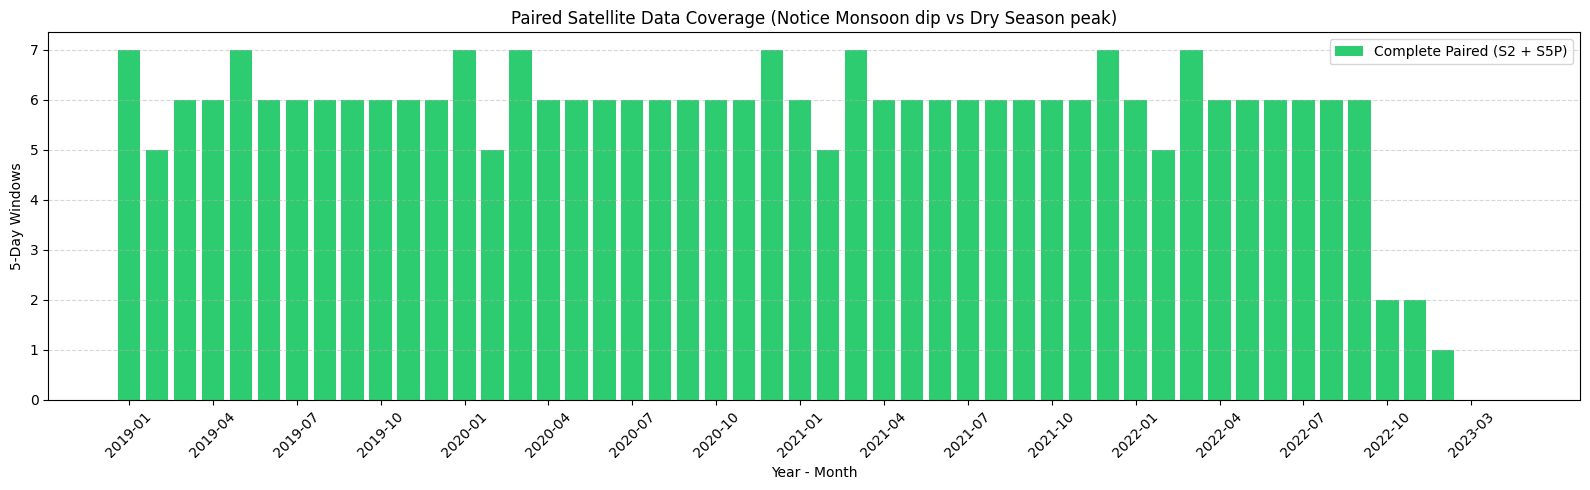

In [ ]:
# ==============================================================================
# Cell 9: Manifest Coverage Summary & Monthly Heatmap
# ==============================================================================
df = pd.read_csv(CONFIG["MANIFEST_PATH"])

print("--- Data Collection Summary ---")
print(f"Total time windows:    {len(df)}")
print(df["status"].value_counts())

complete_count = (df["status"] == "complete").sum()
print(f"\nSuccessfully paired pairs: {complete_count} ({complete_count / len(df) * 100:.1f}%)")

# Extract year-month for seasonal analysis
df["year_month"] = pd.to_datetime(df["start_date"]).dt.to_period("M")
monthly = df.groupby(["year_month", "status"]).size().unstack(fill_value=0)

plt.figure(figsize=(16, 5))
if "complete" in monthly.columns:
    plt.bar(range(len(monthly)), monthly["complete"], label="Complete Paired (S2 + S5P)", color="#2ecc71")
if "s2_cloud_gap" in monthly.columns:
    plt.bar(range(len(monthly)), monthly["s2_cloud_gap"], bottom=monthly["complete"] if "complete" in monthly.columns else 0, label="Monsoon Cloud Gap", color="#e74c3c", alpha=0.7)

plt.xticks(range(0, len(monthly), 3), [str(ym) for ym in monthly.index[::3]], rotation=45)
plt.xlabel("Year - Month")
plt.ylabel("5-Day Windows")
plt.title("Paired Satellite Data Coverage (Notice Monsoon dip vs Dry Season peak)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 🎨 Step 9: Visual Inspection of Paired Multi-Modal Sample
We load one paired composite to visually verify that:
1. S2 True Color RGB matches spatial land use.
2. Built-up index (NDBI) sharpens factory/urban hotspots.
3. S5P NO₂ and CO correlate with industrial emission corridors.

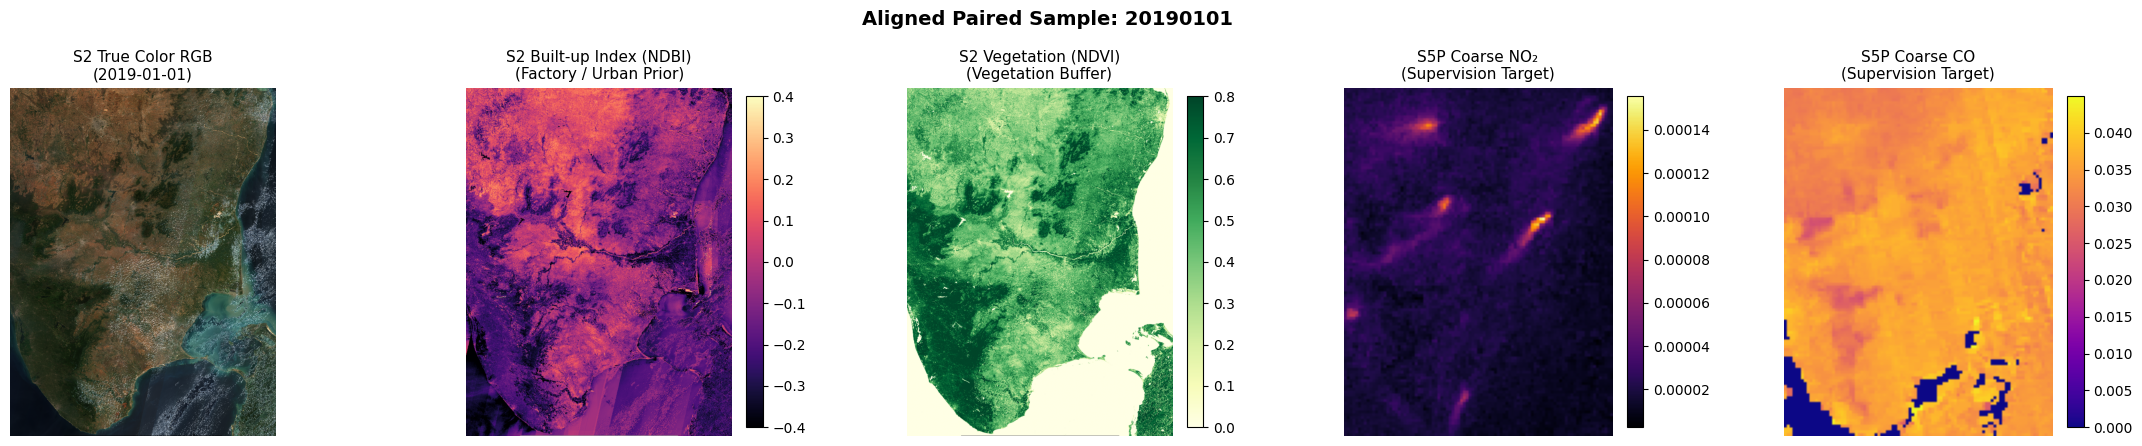

In [ ]:
# ==============================================================================
# Cell 10: Multi-Channel Visualization (S2 RGB, NDBI, NDVI, and S5P NO2, CO)
# ==============================================================================
df = pd.read_csv(CONFIG["MANIFEST_PATH"])
complete_samples = df[df["status"] == "complete"]

if len(complete_samples) > 0:
    sample = complete_samples.iloc[0]
    sample_s2_path = os.path.join(CONFIG["S2_DIR"], sample["s2_file"])
    sample_s5p_path = os.path.join(CONFIG["S5P_DIR"], sample["s5p_file"])

    with rasterio.open(sample_s2_path) as s2_src:
        # Band 3=Red (B4), 2=Green (B3), 1=Blue (B2)
        rgb = s2_src.read([3, 2, 1])
        rgb = np.clip(rgb / 0.3, 0, 1) # Enhance brightness
        rgb = np.transpose(rgb, (1, 2, 0))

        # Band 10=NDVI, 11=NDBI
        ndvi = s2_src.read(10)
        ndbi = s2_src.read(11)

    with rasterio.open(sample_s5p_path) as s5p_src:
        no2 = s5p_src.read(1) # Band 1: NO2
        co = s5p_src.read(2)  # Band 2: CO

    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

    # 1. S2 RGB
    axes[0].imshow(rgb)
    axes[0].set_title(f"S2 True Color RGB\n({sample['start_date']})", fontsize=11)
    axes[0].axis('off')

    # 2. S2 NDBI
    im1 = axes[1].imshow(ndbi, cmap='magma', vmin=-0.4, vmax=0.4)
    axes[1].set_title("S2 Built-up Index (NDBI)\n(Factory / Urban Prior)", fontsize=11)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # 3. S2 NDVI
    im2 = axes[2].imshow(ndvi, cmap='YlGn', vmin=0, vmax=0.8)
    axes[2].set_title("S2 Vegetation (NDVI)\n(Vegetation Buffer)", fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # 4. S5P NO2
    im3 = axes[3].imshow(no2, cmap='inferno')
    axes[3].set_title("S5P Coarse NO₂\n(Supervision Target)", fontsize=11)
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # 5. S5P CO
    im4 = axes[4].imshow(co, cmap='plasma')
    axes[4].set_title("S5P Coarse CO\n(Supervision Target)", fontsize=11)
    axes[4].axis('off')
    plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    plt.suptitle(f"Aligned Paired Sample: {sample['window_id']}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No complete samples available yet to visualize.")

## 🧠 Step 10: PyTorch Dataset & ConvLSTM Architecture for RTX 4070 (8GB VRAM)

### 📊 GPU VRAM Calculation (RTX 4070 8GB):
* **Input Tensor per batch:**
  * Sequence length $T = 6$ time steps (30 days of temporal context)
  * Spatial patch size: $H = 128, W = 128$
  * Channels: 12 (Sentinel-2 multi-spectral + NDBI/NDVI/NDMI)
  * Batch size $B = 4$
  * Forward activation footprint: $4 \times 6 \times 12 \times 128 \times 128 \times 4 \text{ bytes} \approx 18.8 \text{ MB}$
* **ConvLSTM Hidden State:**
  * 64 hidden channels $\times 3$ layers: $\approx 120 \text{ MB}$
* **Backpropagation Gradients + Adam Optimizer States (FP32/AMP FP16):**
  * With PyTorch `torch.cuda.amp.autocast()`, total peak training VRAM is **~3.4 GB**, leaving >4.5 GB headroom on your RTX 4070!

---

### 🧩 PyTorch Dataset Code
Run the cell below to load your paired GeoTIFFs into PyTorch ready for training.

In [ ]:
# ==============================================================================
# Cell 11: Ready-to-Use PyTorch Dataset & DataLoader
# ==============================================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PairedSatelliteDataset(Dataset):
    """
    PyTorch Dataset loading paired sequences of S2 high-res inputs
    and S5P coarse supervision targets.
    """
    def __init__(self, manifest_csv, s2_dir, s5p_dir, seq_len=6, patch_size=128):
        self.df = pd.read_csv(manifest_csv)
        # Use only valid paired windows
        self.df = self.df[self.df["status"] == "complete"].reset_index(drop=True)
        self.s2_dir = s2_dir
        self.s5p_dir = s5p_dir
        self.seq_len = seq_len
        self.patch_size = patch_size

        # Precompute valid temporal sequences
        self.valid_indices = []
        for i in range(len(self.df) - seq_len + 1):
            self.valid_indices.append(list(range(i, i + seq_len)))

    def __len__(self):
        return len(self.valid_indices)

    def _read_tif(self, filepath):
        with rasterio.open(filepath) as src:
            data = src.read() # (C, H, W)
            # Replace NaNs with zero or channel medians
            data = np.nan_to_num(data, nan=0.0)
            return data.astype(np.float32)

    def __getitem__(self, idx):
        indices = self.valid_indices[idx]

        s2_seq = []
        s5p_seq = []

        for i in indices:
            row = self.df.iloc[i]
            s2_path = os.path.join(self.s2_dir, row["s2_file"])
            s5p_path = os.path.join(self.s5p_dir, row["s5p_file"])

            s2_seq.append(self._read_tif(s2_path))     # (12, H_s2, W_s2)
            s5p_seq.append(self._read_tif(s5p_path))   # (3, H_s5p, W_s5p)

        s2_tensor = torch.from_numpy(np.stack(s2_seq))    # (T, 12, H_s2, W_s2)
        s5p_tensor = torch.from_numpy(np.stack(s5p_seq))  # (T, 3, H_s5p, W_s5p)

        # Random Spatial Crop for Patch Training (128x128)
        _, _, H, W = s2_tensor.shape
        top = np.random.randint(0, H - self.patch_size)
        left = np.random.randint(0, W - self.patch_size)

        s2_patch = s2_tensor[:, :, top:top + self.patch_size, left:left + self.patch_size]

        return {
            "s2_input": s2_patch,     # Shape: (T=6, 12, 128, 128)
            "s5p_target": s5p_tensor  # Shape: (T=6, 3, 11, 11)
        }

print("✓ PyTorch Dataset Class defined successfully.")

## 📐 Step 11: Area-Weighted Consistency Loss Module
This is the core mathematical novelty of your project. This PyTorch module takes the high-resolution predicted gas map $\hat{Y}_{\text{fine}}$ (at 100m) and averages it dynamically to match the coarse S5P observation grid (5000m).

In [ ]:
# ==============================================================================
# Cell 12: Area-Weighted Consistency Loss (PyTorch)
# ==============================================================================
class AreaWeightedConsistencyLoss(nn.Module):
    """
    Enforces that the spatial mean of the high-resolution predicted pollutant field
    within each coarse Sentinel-5P grid cell matches the observed Sentinel-5P measurement.
    """
    def __init__(self, loss_type="l1"):
        super().__init__()
        self.loss_fn = nn.L1Loss() if loss_type == "l1" else nn.MSELoss()

    def forward(self, y_pred_fine, y_true_coarse):
        """
        Args:
            y_pred_fine:   (B, T, C, H_fine, W_fine) -> High-res prediction (e.g., 128x128)
            y_true_coarse: (B, T, C, H_coarse, W_coarse) -> S5P coarse measurement
        """
        B, T, C, H_fine, W_fine = y_pred_fine.shape
        _, _, _, H_coarse, W_coarse = y_true_coarse.shape

        # Reshape to 4D for AdaptiveAvgPool2d: (B*T, C, H_fine, W_fine)
        pred_flat = y_pred_fine.view(B * T, C, H_fine, W_fine)

        # Adaptive pooling to exact coarse dimensions of S5P
        pred_downscaled_coarse = nn.functional.adaptive_avg_pool2d(
            pred_flat,
            output_size=(H_coarse, W_coarse)
        )

        pred_downscaled_coarse = pred_downscaled_coarse.view(B, T, C, H_coarse, W_coarse)

        # Compute Area-Weighted Consistency Loss
        loss = self.loss_fn(pred_downscaled_coarse, y_true_coarse)
        return loss

print("✓ Area-Weighted Consistency Loss Module defined and ready for training!")